**Import** **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

**Load Dataset**

In [ ]:
df = pd.read_csv('/content/Sample - Superstore.csv')

**Veiw Data**

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6-16-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10-18-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10-18-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**understand the data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


**Checking missing values**

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Convert Date Column**

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


**Exploratory Data Analysis (EDA)**

**Total Sales**

In [ ]:
df['Sales'].sum()

np.float64(2297200.8603000003)

**Total Customers**

In [ ]:
df['Customer ID'].nunique()

793

**Total Orders**

In [ ]:
df['Order ID'].nunique()

5009

**Sales by Category**

In [ ]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


**Sales by Region**

In [ ]:
df.groupby('Region')['Sales'].sum()

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


**Visualizations**
**Category-wise Sales**

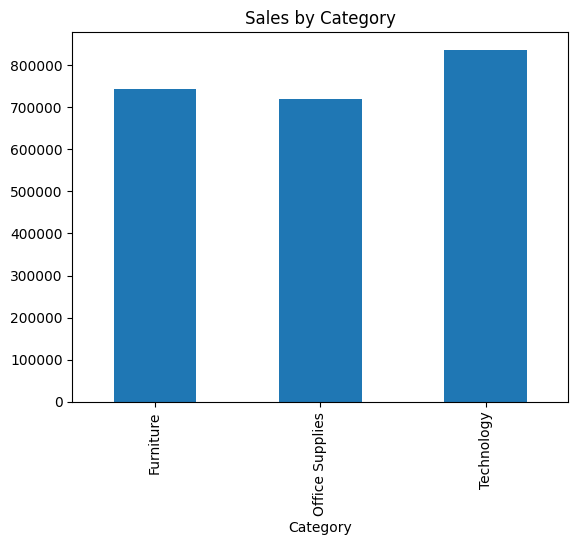

In [ ]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title('Sales by Category')
plt.show()

**Region-wise Sales**

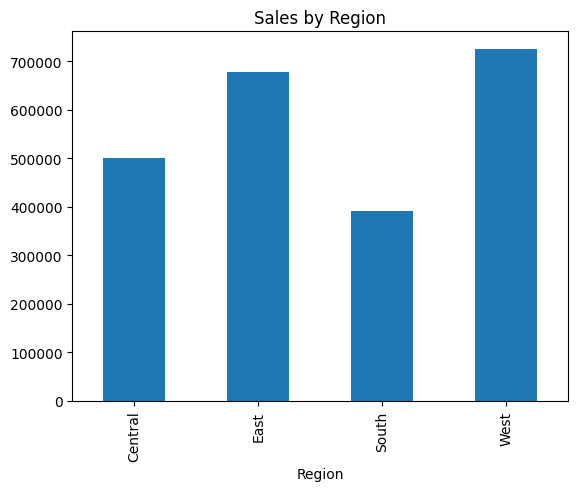

In [ ]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')

plt.title('Sales by Region')
plt.show()

**Product Profitability Analysis**

**Top profitable products:**

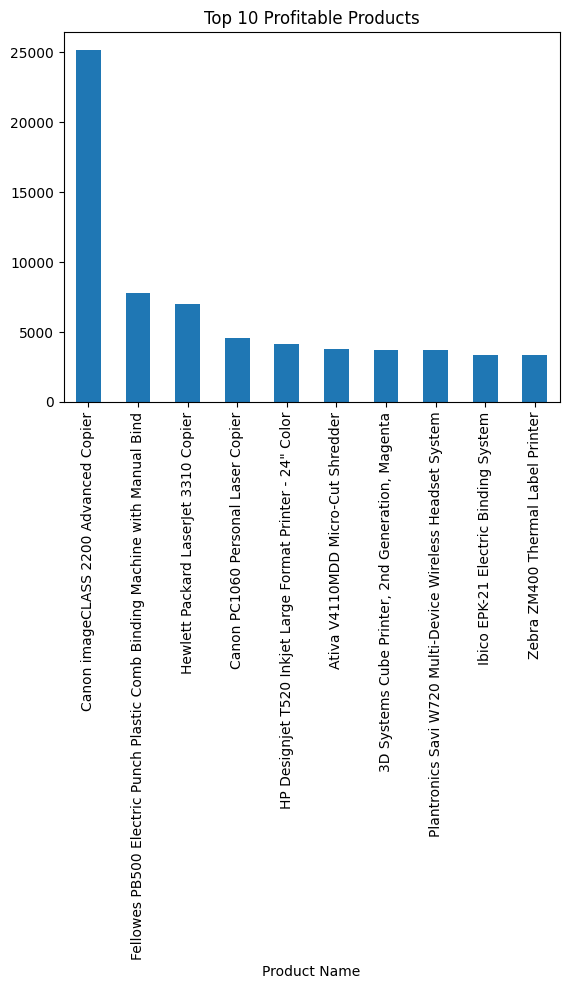

In [ ]:
top_products = df.groupby('Product Name')['Profit'].sum() \
                 .sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title('Top 10 Profitable Products')
plt.show()

**Category profit:**

<Axes: xlabel='Category'>

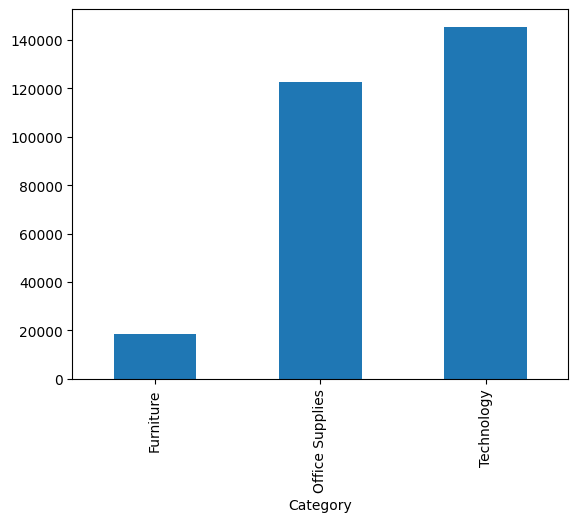

In [ ]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')

**Customer Retention / Churn Metrics**

**Repeat customers:**

In [ ]:
customer_orders = df.groupby('Customer ID')['Order ID'].nunique()

repeat_customers = (customer_orders > 1).sum()

print(repeat_customers)

781


**Purchase frequency distribution:**

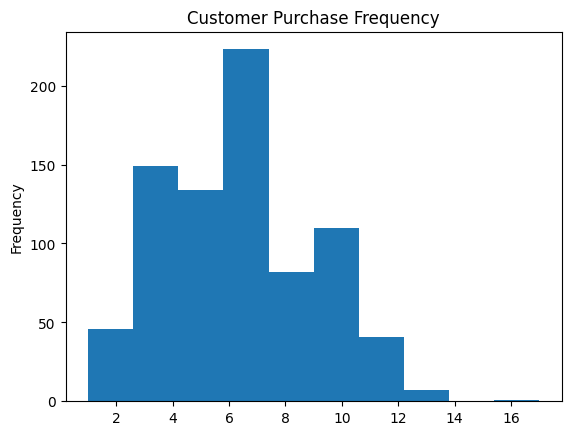

In [ ]:
customer_orders.plot(kind='hist')
plt.title('Customer Purchase Frequency')
plt.show()

**Create RFM Table**

In [ ]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,5,5563.560
AA-10375,20,9,1056.390
AA-10480,260,4,1790.512
AA-10645,56,6,5086.935
AB-10015,416,3,886.156


**Create RFM Scores**

In [ ]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

: **Create Customer Segments**

In [ ]:
def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] == 4:
        return 'Champions'
    elif row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

**Check Results**

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
Customer ID,,,,,,,
AA-10315,185,5,5563.560,1,1,4,At Risk
AA-10375,20,9,1056.390,4,4,1,Champions
AA-10480,260,4,1790.512,1,1,2,At Risk
AA-10645,56,6,5086.935,3,2,4,Potential Loyalists
AB-10015,416,3,886.156,1,1,1,At Risk


**counts for:**

Champions
Loyal Customers
Potential Loyalists
At Risk
Lost Customers

In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
Loyal Customers,323
At Risk,238
Potential Loyalists,159
Champions,73


**Save the File**

In [ ]:
rfm.to_csv('rfm_segments.csv')

**Download The File**

In [ ]:
from google.colab import files

files.download('rfm_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Revenew Forecasting**
**Create Monthly Revenue**

In [ ]:
monthly_revenue = df.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

monthly_revenue.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


**Revenue Trend Chart**

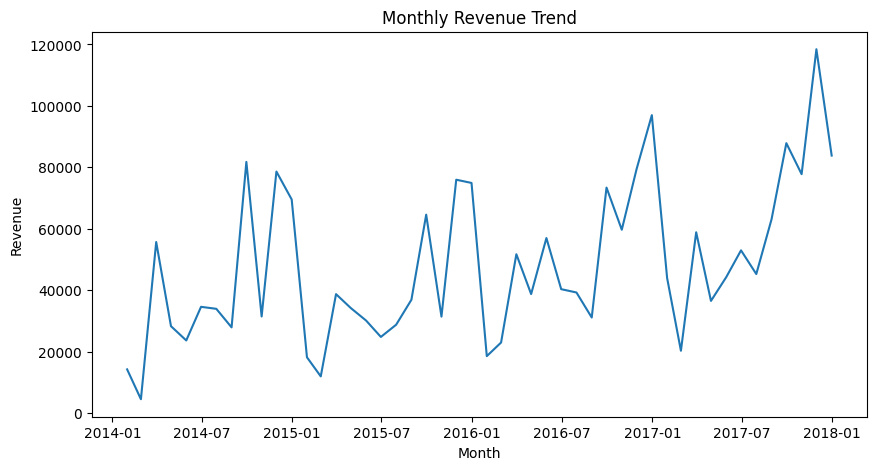

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['Order Date'],
         monthly_revenue['Sales'])

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

**Revenue Trend Chart**

In [ ]:
monthly_revenue['Month_Num'] = range(len(monthly_revenue))

monthly_revenue.head()

,Order Date,Sales,Month_Num
0,2014-01-31,14236.895,0
1,2014-02-28,4519.892,1
2,2014-03-31,55691.009,2
3,2014-04-30,28295.345,3
4,2014-05-31,23648.287,4


**Train the Model**

In [ ]:
X = monthly_revenue[['Month_Num']]
y = monthly_revenue['Sales']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

**Forecast Next 12 Months**

In [ ]:
future_months = np.arange(
    len(monthly_revenue),
    len(monthly_revenue) + 12
).reshape(-1,1)

forecast = model.predict(future_months)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Create Forecast Table**

In [ ]:
forecast_df = pd.DataFrame({
    'Future_Month': range(1,13),
    'Forecast_Revenue': forecast
})

forecast_df

,Future_Month,Forecast_Revenue
0,1,69957.535798
1,2,70859.543330
2,3,71761.550862
3,4,72663.558395
4,5,73565.565927
5,6,74467.573459
6,7,75369.580992
7,8,76271.588524
8,9,77173.596056
9,10,78075.603589


**Forecast Chart**

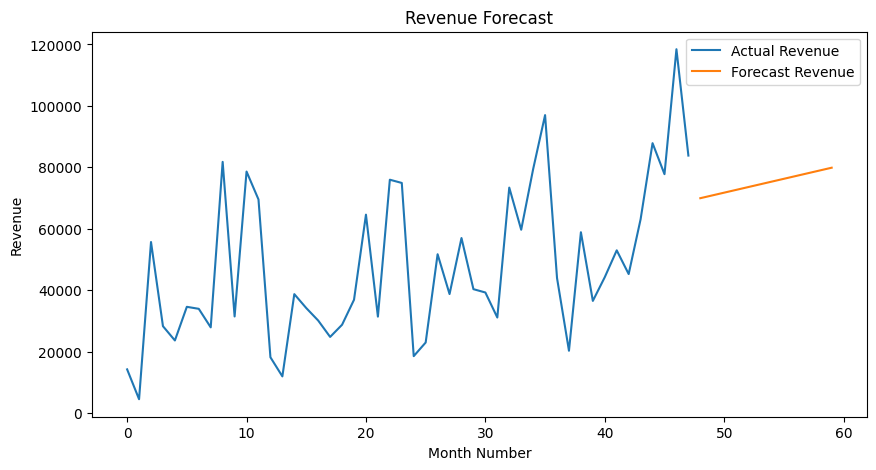

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue['Month_Num'],
    monthly_revenue['Sales'],
    label='Actual Revenue'
)

plt.plot(
    future_months,
    forecast,
    label='Forecast Revenue'
)

plt.title('Revenue Forecast')
plt.xlabel('Month Number')
plt.ylabel('Revenue')
plt.legend()
plt.show()

**Save Forecast Results**

In [ ]:
forecast_df.to_csv('forecast_results.csv', index=False)

**Download The Results**

In [ ]:
from google.colab import files

files.download('forecast_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>